# Decodability

linear probe，看从 embedding 能不能解码出 5 个声学 target。

- 分类 probe: LogisticRegression，metric 是 accuracy 和 macro-F1
- 回归 probe: Ridge，metric 是 MAE 和 R²

因为 baseline train 是 shuffled 顺序保存的，回归用 val 训 test 评。

In [1]:
import os, sys, warnings
warnings.filterwarnings('ignore')

# 让 notebook 不管在哪打开都能 import utils
if not os.path.exists('analysis') and os.path.exists('utils.py'):
    os.chdir('..')
sys.path.insert(0, os.path.abspath('analysis'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import accuracy_score, f1_score, mean_absolute_error, r2_score, confusion_matrix

from utils import load_embeddings, load_continuous_labels, TARGET_NAMES, is_csv_aligned

ENCODERS = ['baseline', 'bewo']

In [2]:
# load 两个 encoder 的 train/val/test
data = {}
for enc in ENCODERS:
    d = {}
    for split in ['train', 'val', 'test']:
        emb, cls = load_embeddings(enc, split)
        d[split] = {'emb': emb, 'cls': cls}
    data[enc] = d
    print(enc, 'train', d['train']['emb'].shape, 'val', d['val']['emb'].shape, 'test', d['test']['emb'].shape)

baseline train (500, 128) val (200, 128) test (140, 128)
bewo train (500, 512) val (200, 512) test (140, 512)


## 分类 probe (train -> test)

In [3]:
rows = []
for enc in ENCODERS:
    d = data[enc]
    for i, name in enumerate(TARGET_NAMES):
        clf = make_pipeline(StandardScaler(), LogisticRegression(max_iter=5000))
        clf.fit(d['train']['emb'], d['train']['cls'][:, i])
        y_pred = clf.predict(d['test']['emb'])
        y_true = d['test']['cls'][:, i]
        rows.append({
            'encoder': enc,
            'target': name,
            'accuracy': round(accuracy_score(y_true, y_pred), 3),
            'macro_f1': round(f1_score(y_true, y_pred, average='macro'), 3),
        })

cls_df = pd.DataFrame(rows).pivot(index='target', columns='encoder', values=['accuracy', 'macro_f1'])
cls_df = cls_df.reindex(TARGET_NAMES)
cls_df

accuracy        macro_f1       
encoder baseline   bewo baseline   bewo
target                                 
DRR        0.950  0.850    0.950  0.847
C80        0.921  0.943    0.920  0.942
RT60       0.971  1.000    0.968  1.000
ILD        0.700  0.600    0.701  0.598
ITD        0.607  0.571    0.609  0.570

## 回归 probe (val -> test)

In [4]:
df_val = load_continuous_labels('val')
df_test = load_continuous_labels('test')
cont_cols = ['DRR', 'C80', 'RT60', 'ILD', 'ITD_ms']
cv = df_val[cont_cols].to_numpy(dtype=np.float32)
ct = df_test[cont_cols].to_numpy(dtype=np.float32)

rows = []
for enc in ENCODERS:
    if not is_csv_aligned(data[enc]['val']['cls'], df_val):
        print(enc, 'val 跟 csv 没对上 - 跳过')
        continue
    val_emb = data[enc]['val']['emb']
    test_emb = data[enc]['test']['emb']
    for i, name in enumerate(TARGET_NAMES):
        reg = make_pipeline(StandardScaler(), Ridge(alpha=1.0))
        reg.fit(val_emb, cv[:, i])
        y_pred = reg.predict(test_emb)
        rows.append({
            'encoder': enc,
            'target': name,
            'MAE': round(mean_absolute_error(ct[:, i], y_pred), 4),
            'R2': round(r2_score(ct[:, i], y_pred), 3),
        })

reg_df = pd.DataFrame(rows).pivot(index='target', columns='encoder', values=['MAE', 'R2'])
reg_df = reg_df.reindex(TARGET_NAMES)
reg_df

MAE               R2       
encoder baseline    bewo baseline   bewo
target                                  
DRR       1.2749  1.3884    0.935  0.905
C80       1.4233  1.0812    0.976  0.987
RT60      0.0756  0.0800    0.925  0.919
ILD       0.5208  0.6216    0.264 -0.155
ITD       0.9276  1.1773   -0.445 -0.975

## 混淆矩阵

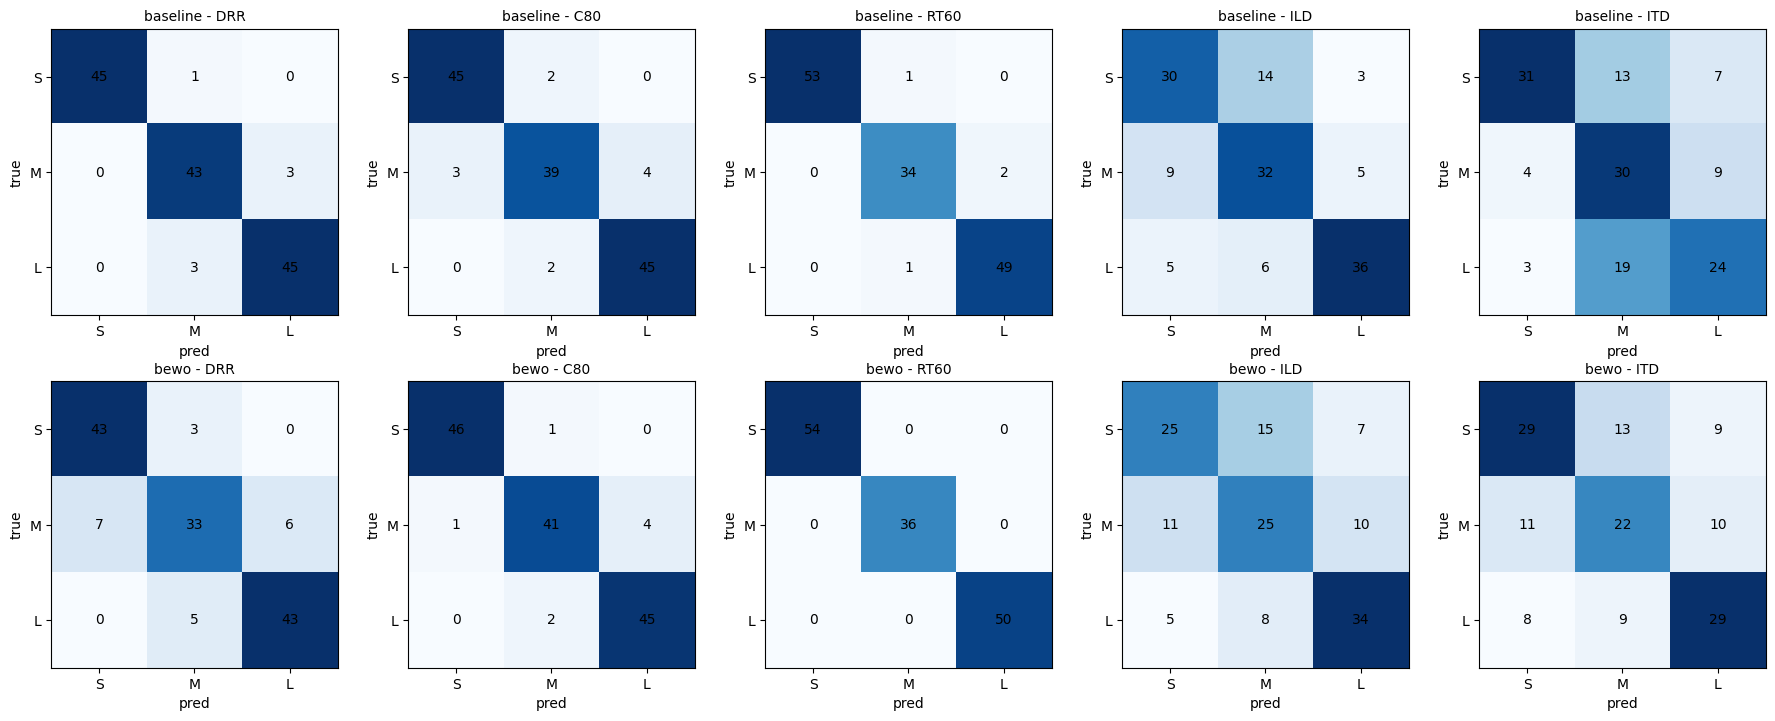

In [5]:
fig, axes = plt.subplots(len(ENCODERS), len(TARGET_NAMES), figsize=(3.6*len(TARGET_NAMES), 3.6*len(ENCODERS)))
for r, enc in enumerate(ENCODERS):
    d = data[enc]
    for c, name in enumerate(TARGET_NAMES):
        clf = make_pipeline(StandardScaler(), LogisticRegression(max_iter=5000))
        clf.fit(d['train']['emb'], d['train']['cls'][:, c])
        cm = confusion_matrix(d['test']['cls'][:, c], clf.predict(d['test']['emb']), labels=[0,1,2])
        ax = axes[r, c]
        ax.imshow(cm, cmap='Blues')
        ax.set_title(f'{enc} - {name}', fontsize=10)
        ax.set_xlabel('pred')
        ax.set_ylabel('true')
        ax.set_xticks([0,1,2], ['S','M','L'])
        ax.set_yticks([0,1,2], ['S','M','L'])
        for i in range(3):
            for j in range(3):
                ax.text(j, i, cm[i, j], ha='center', va='center')

plt.tight_layout()
plt.savefig('analysis/figs/01_confusion.png', dpi=120, bbox_inches='tight')
plt.show()

## 看看

- DRR/C80/RT60 两个 encoder 都能解码得不错（>85%）
- ILD/ITD 都很差，回归 R² 甚至是负的——大概率是 mel-spectrogram 输入丢了双耳交互信息
- bewo 在 RT60 上拿到 100%（因为它训练任务里就有 RT60）